Reservation wage without growth = 15.605680485470918
Reservation wage with growth = 15.423058639190002


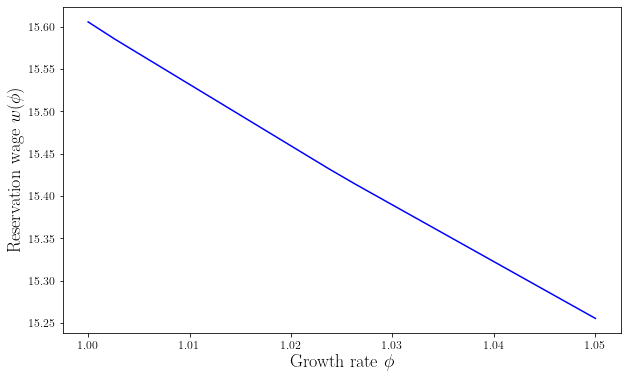

In [1]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

# TeX Support for plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

def betabinomial(n, a, b):

    k = np.linspace(0, n, n + 1)
    probs = sp.binom(n, k)*sp.beta(k + a, n - k + b) / sp.beta(a, b)

    return probs


def vfi_mccall_growth(wages, probs, v_guess, betta, c, phi, maxiter=10000, tol=10e-4):

    v_new = np.zeros(len(wages))

    # Value Function Iteration
    for iter1 in range(maxiter):

        # Calculate the new V given your guess and the wage distribution
        v_new = np.maximum(wages/ (1.0 - betta*phi),c + betta * np.sum(v_guess * probs))
        
        # Calculate the distance between successive iterations
        # The distance here is the maximum element of the absolute difference between successive iterates
        distance = np.amax(np.abs(v_new - v_guess))
        
        # Print the distance
        # print(iter1, distance)
        
        # If the distance is sufficiently small, break the loop
        if distance < tol:
            break

        # Adjust the guess
        v_guess[:] = v_new

    # calculate the reservation wage
    reservation_wage = (1.0 - betta*phi) * (c + betta * np.sum(v_new * probs))

    return reservation_wage, v_new



# Generate a wage distribution with
# 60 different wages ranging from 10.0 to 20.0
n = 60
w_min = 10.0
w_max = 20.0

# beta-binomial distribution parameters
a = 600.0
b = 400.0

# calculate probabilities\n",
wages = np.linspace(w_min,w_max,n)
probs = betabinomial(n-1,a,b)


betta = 0.95
c = 6.0
phi= 1.025

# calculate reservation wage and the value function
result = vfi_mccall_growth(wages, probs, np.zeros(n), betta, c, 1.0 )

print("Reservation wage without growth =", result[0])

result = vfi_mccall_growth(wages, probs, np.zeros(n), betta, c, phi )

print("Reservation wage with growth =", result[0])

##============================================================================##

n_phi = 20
phi_seq = np.linspace(1.0,1.05,n_phi)
res_wage_phi = np.zeros(n_phi)

for i1 in range(n_phi):
    res_wage_phi[i1],_ = vfi_mccall_growth(wages, probs, np.zeros(n), betta, c, phi_seq[i1])


# Set up a figure
fig,ax=plt.subplots(figsize=(10,6))
ax.plot(phi_seq, res_wage_phi, color='blue', label='$w(\phi)$')
#plt.xlim((10,20))
plt.rc('axes', titlesize=18)
plt.rc('axes', labelsize=18)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
#ax.legend(loc='upper right',fontsize=18)
ax.set_xlabel('Growth rate $\phi$', fontsize=18)
ax.set_ylabel('Reservation wage $w(\phi)$', fontsize=18)
plt.show()
